## Import des Librairies

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import perceval as pcvl
import sklearn.svm
import torch
from tqdm import tqdm
from sklearn.decomposition import PCA
import merlin
import os
import gzip
from torch.utils.data import TensorDataset, DataLoader


## Class result

Utile pour garder les résultats, pas sûr que ce soit vraiment la meilleure manière de faire

In [ ]:
class result():
    def __init__(self, g, var_FQK, var_RBF, var_RBF_order_2, F,eta_max, ROC_AUC, expressivity):
        self.var_FQK = var_FQK
        self.var_RBF = var_RBF
        self.var_RBF_order_2 = var_RBF_order_2
        self.g = g
        self.F = F
        self.eta_max = eta_max
        self.ROC_AUC = ROC_AUC
        self.expressivity = expressivity

## Préprocessing

### Importation du dataset

In [ ]:
def charger_images_mnist_torch(chemin_fichier):
    """Lit le fichier d'images et retourne un tenseur PyTorch normalisé (B, C, H, W)."""
    with gzip.open(chemin_fichier, 'rb') as f:
        donnees = np.frombuffer(f.read(), np.uint8, offset=16)
   
    # 1. Conversion en tableau NumPy puis en Tenseur PyTorch
    images_np = donnees.reshape(-1, 28, 28)
    un_tensor = torch.from_numpy(images_np)
   
    # 2. Conversion en float32 et normalisation entre 0.0 et 1.0
    un_tensor = un_tensor.float() / 255.0
   
    # 3. Ajout de la dimension du canal (grayscale -> 1 canal) à la position 1
    # Passe de (60000, 28, 28) à (60000, 1, 28, 28)
    un_tensor = un_tensor.unsqueeze(1)
   
    return un_tensor

def charger_labels_mnist_torch(chemin_fichier):
    """Lit le fichier de labels et retourne un tenseur PyTorch de type Long."""
    with gzip.open(chemin_fichier, 'rb') as f:
        donnees = np.frombuffer(f.read(), np.uint8, offset=8)
   
    # Conversion en tenseur et forçage en type Long (requis pour la classification)
    return torch.from_numpy(donnees).long()

# --- CONFIGURATION DES CHEMINS (Identique) ---
dossier_base = os.path.join('data', 'Importance-of-Kernel-Bandwidth-in-Quantum-Machine-Learning', 'data', 'fashion_mnist')

chemin_train_images = os.path.join(dossier_base, 'train-images-idx3-ubyte.gz')
chemin_train_labels = os.path.join(dossier_base, 'train-labels-idx1-ubyte.gz')
chemin_test_images = os.path.join(dossier_base, 't10k-images-idx3-ubyte.gz')
chemin_test_labels = os.path.join(dossier_base, 't10k-labels-idx1-ubyte.gz')

# --- CHARGEMENT DIRECT EN TENSEURS ---
X_train_tensor = charger_images_mnist_torch(chemin_train_images)
y_train_tensor = charger_labels_mnist_torch(chemin_train_labels)

X_test_tensor = charger_images_mnist_torch(chemin_test_images)
y_test_tensor = charger_labels_mnist_torch(chemin_test_labels)


masque_train = (y_train_tensor == 2) | (y_train_tensor == 8)
masque_test = (y_test_tensor == 2) | (y_test_tensor == 8)

X_train_tensor = X_train_tensor[masque_train]
y_train_tensor = y_train_tensor[masque_train]

X_test_tensor = X_test_tensor[masque_test]
y_test_tensor = y_test_tensor[masque_test]


# --- VÉRIFICATION DES FORMATS ---
print("--- Formats des Tenseurs PyTorch ---")
print(f"X_train : {X_train_tensor.shape} | Type : {X_train_tensor.dtype}")
# Sortie attendue : torch.Size([60000, 1, 28, 28]) | torch.float32
print(f"y_train : {y_train_tensor.shape} | Type : {y_train_tensor.dtype}")
# Sortie attendue : torch.Size([60000]) | torch.int64



--- Formats des Tenseurs PyTorch ---
X_train : torch.Size([12000, 1, 28, 28]) | Type : torch.float32
y_train : torch.Size([12000]) | Type : torch.int64


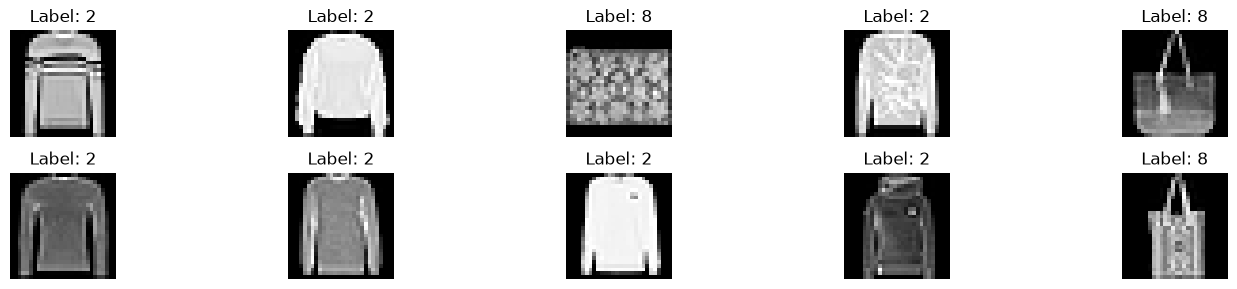

In [11]:
nb_images = 10

fig,axes = plt.subplots(2, nb_images//2, figsize=(15, 3))
axes = axes.flatten()
for i in range(nb_images):
    image_tensor = X_train_tensor[i].squeeze(0)  # Retirer la dimension du canal
    label_tensor = y_train_tensor[i]

    axes[i].imshow(image_tensor, cmap='gray')

    axes[i].set_title(f"Label: {label_tensor.item()}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Reduction du Dataset + PCA

In [ ]:
def subset_PCA(X_train, y_train, X_test, y_test, nb_train, nb_test, dim = -1, seed = 42):
    """Extrait un sous-ensemble des données et applique PCA pour réduire la dimensionnalité."""
    
    torch.manual_seed(seed)  # Pour la reproductibilité
    
    indices_train = torch.randperm(X_train.size(0))[:nb_train]
    indices_test = torch.randperm(X_test.size(0))[:nb_test]
   
    X_train_subset = X_train[indices_train].view(nb_train, -1).numpy()  # Aplatir les images
    y_train_subset = y_train[indices_train]
    X_test_subset = X_test[indices_test].view(nb_test, -1).numpy()  # Aplatir les images
    y_test_subset = y_test[indices_test]
    
    if dim != -1:
        # Appliquer PCA pour réduire à 'dim' dimensions
        pca = PCA(n_components=dim)
        X_train = pca.fit_transform(X_train_subset)
        X_test = pca.transform(X_test_subset)
    
    return torch.from_numpy(X_train).float(), y_train_subset, torch.from_numpy(X_test).float(), y_test_subset

## Calcul des métriques

### Calcul de $g(\textbf{K}_C,\textbf{K}_Q)$

In [ ]:
def matrix_sqrt(A): 
    """ Calcule la racine carrée matricielle d'une matrice symétrique semi-définie positive. """ 
    # Décomposition en valeurs propres (A = V * L * V^T) 
    L, V = torch.linalg.eigh(A)
    # Parfois, les erreurs de précision numérique créent des valeurs propres 
    # très légèrement négatives (ex: -1e-15). On les force à être positives ou nulles. 
    L = torch.clamp(L, min=0.0) 
    # Reconstruction : V * sqrt(L) * V^T 
    return V @ torch.diag(torch.sqrt(L)) @ V.T

def calculate_g(K1, K2): 
    """ Calcule g(K1, K2) avec lambda = 0. """ 
    # 1. Calcul de l'inverse de K2
    # Utilisation de pseudo-inverse (pinv) est plus sûr que inv()
    # car une matrice de noyau (K2) peut avoir un déterminant proche de 0. 
    K2_inv = torch.linalg.pinv(K2)
    # 2. Calcul de la racine carrée matricielle de K1 
    sqrt_K1 = matrix_sqrt(K1) 
    # 3. Produit matriciel central : sqrt(K1) @ K2^-1 @ sqrt(K1) 
    inner_matrix = sqrt_K1 @ K2_inv @ sqrt_K1 
    # 4. Norme spectrale (la plus grande valeur singulière, équivalente à ord=2) 
    spectral_norm = torch.linalg.matrix_norm(inner_matrix, ord=2) 
    # 5. Racine carrée finale de la formule 
    g = torch.sqrt(spectral_norm) 
    return g

# Vestige du papier reproduit 
def calculate_expressivity(K):
    return 0

### Calcul de $\eta_{max}$

In [ ]:
def calculate_eta_max(K):
    L,V = torch.linalg.eigh(K)
    eta_max = L[-1]
    return eta_max

### Calcul de $F(\textbf{K}_C,\textbf{K}_Q)$

In [1]:
def calculate_kernel_distance_F(K_C, K_Q):
   """
   Calcule F(K_C, K_Q), la distance relative de Frobenius entre deux matrices de noyau.
   K_C : Tenseur PyTorch représentant la matrice de noyau classique.
   K_Q : Tenseur PyTorch représentant la matrice de noyau quantique.
   """
   # 1. Calcul du numérateur : Norme de Frobenius de la différence
   numerateur = torch.linalg.matrix_norm(K_C - K_Q, ord='fro')

   # 2. Calcul du dénominateur : Norme de Frobenius de K_Q
   denominateur = torch.linalg.matrix_norm(K_Q, ord='fro')

   # 3. Ratio final
   F = numerateur / denominateur

   return F

## Fonction d'entrainement de modèle

In [2]:
def train(X_train, y_train_1D, X_test, y_test_1D, bandwidth = 1.0, n_modes = -1, redundancy = False):

    X_train = X_train * bandwidth
    X_test = X_test * bandwidth

    if n_modes == -1:
        n_modes = X_train.shape[1] + 1
    if n_modes < X_train.shape[1] + 1:
        raise ValueError(f"n_modes must be at least {X_train.shape[1] + 1} for the given input size.")


    builder = merlin.CircuitBuilder(n_modes=n_modes)
    builder.add_entangling_layer(trainable=True, model="mzi", name="left")
    builder.add_angle_encoding(modes=[i for i in range(X_train.shape[1])], name="phi")
    builder.add_entangling_layer(trainable=True, model="mzi", name="right")

    feature_map = merlin.FeatureMap.simple(input_size=X_train.shape[1])  # n_modes = input_size + 1 = 5
    fidelity_kernel = merlin.FidelityKernel(
        feature_map=feature_map,
        input_state=[1 - (i % 2) for i in range(n_modes)],  # alternating photons for n_modes
        computation_space=merlin.ComputationSpace.FOCK,
    )

    svc = sklearn.svm.SVC(kernel="precomputed")

    K_train = fidelity_kernel(X_train)
    K_test = fidelity_kernel(X_test, X_train)


    svc.fit(K_train.detach().numpy(), y_train_1D.detach().numpy())
    test_accuracy = svc.score(K_test.detach().numpy(), y_test_1D.detach().numpy())

    #Calcul du kernel RBF
    distances = torch.cdist(X_train, X_train, p=2)
    distances_carré = distances ** 2
    K_rbf = torch.exp(-distances_carré)

    #Calcul du kernel RBF ordre 2
    distances = torch.cdist(X_train, X_train, p=2)
    z = distances ** 2
    K_rbf_order_2 = 1.0 - z + 0.5*(z**2)


    F = calculate_kernel_distance_F(K_train, K_rbf)
    eta_max = calculate_eta_max(K_train)
    ROC_AUC = sklearn.metrics.roc_auc_score(y_test_1D.detach().numpy(), svc.decision_function(K_test.detach().numpy()))

    return result(calculate_g(K_train,K_rbf).item(), K_train.var(correction=False).item(), K_rbf.var(correction=False).item(), K_rbf_order_2.var(correction=False).item(), F.item(), eta_max.item(), ROC_AUC, calculate_expressivity(K_train))


In [ ]:
x,y_g,y_FQK,y_RBF,y_RBF_order_2,y_F,y_eta_max,y_ROC_AUC = [],[],[],[],[],[],[],[]

for i in np.logspace(-3, 3, 60):
    res = train(X_train, y_train_1D, X_test, y_test_1D, bandwidth=i)
    y_g.append(res.g)
    y_FQK.append(res.var_FQK)
    y_RBF.append(res.var_RBF)
    y_RBF_order_2.append(res.var_RBF_order_2)
    y_F.append(res.F)
    y_eta_max.append(res.eta_max)
    y_ROC_AUC.append(res.ROC_AUC)
    x.append(i)
    print(i)

## Affichage des résultats

In [ ]:
# Création de la figure et d'une grille de 6 graphiques
# figsize=(15, 5) permet d'avoir une image bien large
fig, axes = plt.subplots( 2, 3, figsize=(15, 10))

# ==========================================
# Subplot 1 : Les Variances (FQK et RBF)
# ==========================================
axes[0,0].loglog(x, y_FQK, label="FQK", marker='o', linestyle='-')
axes[0,0].loglog(x, y_RBF, label="RBF", marker='s', linestyle='-')

axes[0,0].set_title("Variances des noyaux")
axes[0,0].set_xlabel("Bandwidth (i)")
axes[0,0].set_ylabel("Variance")
axes[0,0].legend() # Affiche la légende pour différencier les 3 courbes
axes[0,0].grid(True, which="both", ls="--", alpha=0.5) # Ajoute une grille lisible en log

# ==========================================
# Subplot 2 : La métrique g
# ==========================================
axes[0,1].loglog(x, y_g, color='purple', marker='d', linestyle='-')

axes[0,1].set_title("Métrique g")
axes[0,1].set_xlabel("Bandwidth (i)")
axes[0,1].set_ylabel("g(KC, KQ)")
axes[0,1].grid(True, which="both", ls="--", alpha=0.5)

# ==========================================
# Subplot 3 : La distance F
# ==========================================
axes[1,0].loglog(x, y_F, color='green', marker='v', linestyle='-')

axes[1,0].set_title("Distance de Frobenius (F)")
axes[1,0].set_xlabel("Bandwidth (i)")
axes[1,0].set_ylabel("F(KC, KQ)")
axes[1,0].grid(True, which="both", ls="--", alpha=0.5)

# ==========================================
# Subplot 4 : eta_max
# ==========================================
axes[1,1].loglog(x, y_eta_max, color='orange', marker='^', linestyle='-')

axes[1,1].set_title("eta_max")
axes[1,1].set_xlabel("Bandwidth (i)")
axes[1,1].set_ylabel("eta_max(K)")
axes[1,1].grid(True, which="both", ls="--", alpha=0.5)


# ==========================================
# Subplot 5 : ROC AUC
# ==========================================
axes[0,2].semilogx(x, y_ROC_AUC, color='red', marker='s', linestyle='-')

axes[0,2].set_title("ROC AUC")
axes[0,2].set_xlabel("Bandwidth (i)")
axes[0,2].set_ylabel("ROC AUC")
axes[0,2].grid(True, which="both", ls="--", alpha=0.5)

# ==========================================
# Subplot 6 : VAR(RBF_order_2)
# ==========================================
axes[1,2].loglog(x, y_RBF_order_2, color='blue', marker='x', linestyle='-')

axes[1,2].set_title("Variance du noyau RBF (ordre 2)")
axes[1,2].set_xlabel("Bandwidth (i)")
axes[1,2].set_ylabel("Variance")
axes[1,2].grid(True, which="both", ls="--", alpha=0.5)

# ==========================================
# Affichage propre
# ==========================================
# tight_layout empêche les titres et les labels de se chevaucher
plt.tight_layout() 
plt.show()